In [ ]:
%pip install torchvision

In [35]:
import torch 
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
import torchvision
import numpy as np 
import matplotlib.pyplot as plt


In [3]:
import sys
print(sys.executable)

c:\Users\abdul\AppData\Local\Programs\Python\Python313\python.exe


In [4]:
%pip install torchvision

   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ---------------------- ----------------- 2.4/4.2 MB 13.4 MB/s eta 0:00:01
   ---------------------------------------- 4.2/4.2 MB 12.7 MB/s  0:00:00
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
    --------------------------------------- 2.6/122.1 MB 13.5 MB/s eta 0:00:09
   - -------------------------------------- 5.5/122.1 MB 13.4 MB/s eta 0:00:09
   -- ------------------------------------- 8.1/122.1 MB 13.4 MB/s eta 0:00:09
   --- ------------------------------------ 10.7/122.1 MB 13.4 MB/s eta 0:00:09
   ---- ----------------------------------- 13.4/122.1 MB 13.3 MB/s eta 0:00:09
   ----- ---------------------------------- 16.3/122.1 MB 13.3 MB/s eta 0:00:08
   ------ --------------------------------- 19.1/122.1 MB 13.3 MB/s eta 0:00:08
   ------- -------------------------------- 21.8/122.1 MB 13.3 MB/s eta 0:00:08
   ------- -------------------------------- 24.4/122.1 MB 13.3 MB/s eta 

  You can safely remove it manually.

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [61]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [62]:
g = torch.Generator().manual_seed(SEED)

In [7]:
root= r'C:\Users\abdul\Desktop\Projekte\Python\Giris\dataset'
DATASET_NAME='CIFAR10'

In [8]:
base_train=datasets.CIFAR10(root=root, train=True, download=True, transform=None)
base_test=datasets.CIFAR10(root=root, train=False, download=True, transform=None)
classes=base_train.classes

#### Dataset

In [44]:
from re import S
from PIL import Image
from sympy.solvers.diophantine.diophantine import length


class CIFARDataset(Dataset):
    def __init__(self, ds, indices=None, transforms=None):
        self.data = ds.data
        self.targets = ds.targets

        if indices is None:
          self.indices = list(range(len(self.data)))
        else:
          self.indices = list(indices)
          
        self.transforms = transforms

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, target = self.data[self.indices[idx]], self.targets[self.indices[idx]]

        img = Image.fromarray(img)
        if self.transforms:
            img = self.transforms(img)
        return img, target



In [68]:
validation_ratio = 0.1
N = len(base_train)
validation_size = int(N * validation_ratio)

perm = torch.randperm(N, generator=g)
train_indices = perm[validation_size:].tolist()
val_indices = perm[:validation_size].tolist()

print('Base Train Size:', len(base_train) )
print('Validation Size:', validation_size) 
perm

Base Train Size: 50000
Validation Size: 5000


tensor([ 8863, 20961, 15672,  ..., 31634, 31068,  2951])

In [24]:
mean, std = (0.4917, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)

train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [28]:
train_ds = CIFARDataset(base_train, indices=train_indices, transforms=train_transforms)
val_ds = CIFARDataset(base_train, indices=val_indices, transforms=val_transforms)
test_ds = CIFARDataset(base_test, transforms=val_transforms)

In [31]:
print("Train Size:", len(train_ds))
print("Validation Size:", len(val_ds))
print("Test Size:", len(test_ds))

Train Size: 45000
Validation Size: 5000
Test Size: 10000


####  Dataloader

In [74]:
BATCH_SIZE = 128
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=pin_memory, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin_memory, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin_memory, num_workers=0)

print("Train Loader Size:", len(train_loader))
print("Validation Loader Size:", len(val_loader))
print("Test Loader Size:", len(test_loader))
print("Pin_Memory:", pin_memory)

Train Loader Size: 352
Validation Loader Size: 40
Test Loader Size: 79
Pin_Memory: False


In [85]:
x, y = next(iter(train_loader))
print("Batch X shape:", x.shape)
print("Batch X dtype:", x.dtype)
print("Batch Y shape:", y.shape)
print("Batch Y dtype:", y.dtype)

Batch X shape: torch.Size([128, 3, 32, 32])
Batch X dtype: torch.float32
Batch Y shape: torch.Size([128])
Batch Y dtype: torch.int64


In [76]:
mean_t = torch.tensor(mean).view(len(mean),1 ,1)
std_t = torch.tensor(std).view(len(std),1 ,1)

def unnormalize(x_image):
    return x_image * std_t + mean_t

print(mean_t)
print(std_t)

tensor([[[0.4917]],

        [[0.4822]],

        [[0.4465]]])
tensor([[[0.2470]],

        [[0.2435]],

        [[0.2616]]])


In [86]:
grid = torchvision.utils.make_grid(unnormalize(x[:32]))

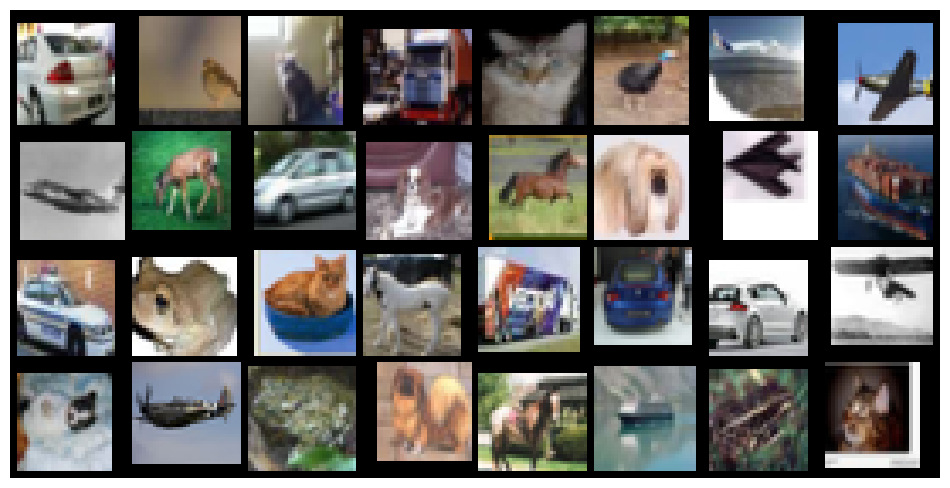

In [87]:
plt.figure(figsize=(12, 12))
if grid.shape[0] == 1:
    plt.imshow(grid.squeeze(0), cmap="gray")
else: 
    plt.imshow(grid.permute(1, 2, 0).clamp(0, 1))
plt.axis("off")
plt.show()

In [90]:
print("İlk 32 görüntünün sınıfları:", [classes[int(y)] for y in y[:32]])

İlk 32 görüntünün sınıfları: ['automobile', 'bird', 'cat', 'truck', 'cat', 'bird', 'airplane', 'airplane', 'airplane', 'deer', 'automobile', 'dog', 'horse', 'dog', 'airplane', 'ship', 'automobile', 'frog', 'cat', 'horse', 'truck', 'automobile', 'automobile', 'airplane', 'dog', 'airplane', 'frog', 'dog', 'horse', 'ship', 'frog', 'cat']
